In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your LoRA CSV
lora_df = pd.read_csv('deliverables/lora_all_experiments.csv')  # Update path

lora_df.columns

Index(['CASE GIT', 'CHANGE', 'timestamp', 'training_time_mins', 'base_model',
       'dataset', 'num_samples', 'lora_r', 'lora_alpha', 'lora_dropout',
       'lora_target_modules', 'epochs', 'learning_rate', 'batch_size',
       'grad_accum', 'max_length', 'bleu_base_avg', 'bleu_lora_avg',
       'analysis', 'q1_base', 'q1_lora', 'bleu1_base', 'bleu1_lora', 'q2_base',
       'q2_lora', 'bleu2_base', 'bleu2_lora', 'q3_base', 'q3_lora',
       'bleu3_base', 'bleu3_lora', 'q4_base', 'q4_lora', 'bleu4_base',
       'bleu4_lora', 'q5_base', 'q5_lora', 'bleu5_base', 'bleu5_lora',
       'q6_base', 'q6_lora', 'bleu6_base', 'bleu6_lora', 'q7_base', 'q7_lora',
       'bleu7_base', 'bleu7_lora', 'q8_base', 'q8_lora', 'bleu8_base',
       'bleu8_lora', 'q9_base', 'q9_lora', 'bleu9_base', 'bleu9_lora',
       'q10_base', 'q10_lora', 'bleu10_base', 'bleu10_lora'],
      dtype='object')

C:\Users\DELL\AppData\Local\Temp\ipykernel_28528\122288376.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CASE', y='bleu_lora_avg', data=lora_df, palette='coolwarm')


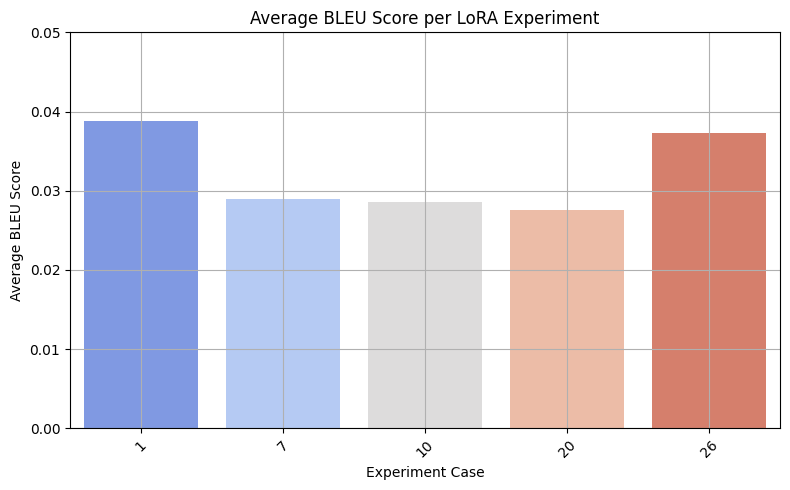

In [17]:
# Identify BLEU columns excluding those with 'base' in the name
bleu_columns = [
    col for col in lora_df.columns
    if 'BLEU' in col.upper() and 'BASE' not in col.upper()
]

# Convert BLEU columns to numeric (in case they are strings)
for col in bleu_columns:
    lora_df[col] = pd.to_numeric(lora_df[col], errors='coerce')

# Plot Average BLEU per Experiment
plt.figure(figsize=(8, 5))
sns.barplot(x='CASE', y='bleu_lora_avg', data=lora_df, palette='coolwarm')
plt.title("Average BLEU Score per LoRA Experiment")
plt.ylabel("Average BLEU Score")
plt.xlabel("Experiment Case")
plt.ylim(0, 0.05)
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


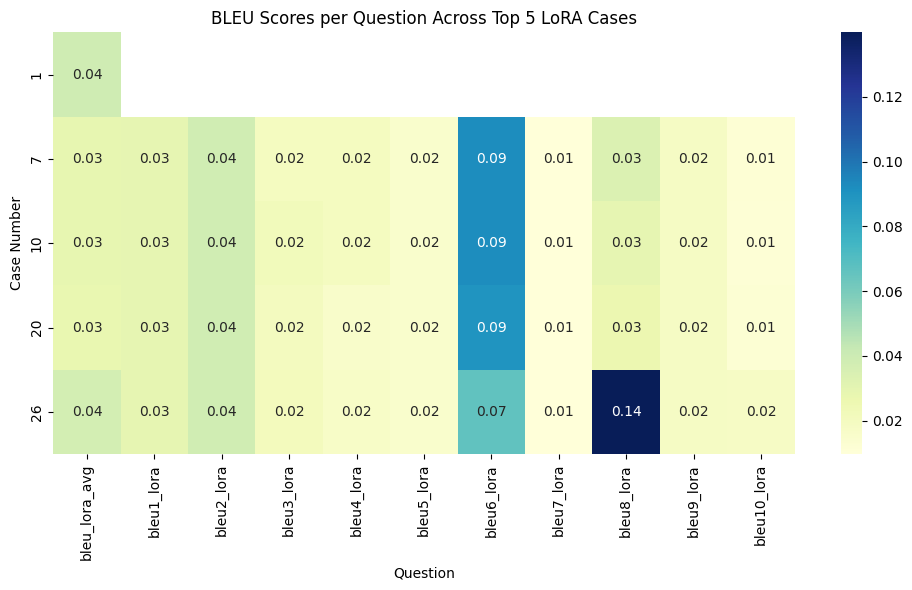

In [18]:
# Prepare BLEU score matrix
bleu_matrix = lora_df.set_index('CASE')[bleu_columns]

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(bleu_matrix, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title("BLEU Scores per Question Across Top 5 LoRA Cases")
plt.xlabel("Question")
plt.ylabel("Case Number")
plt.tight_layout()
plt.show()


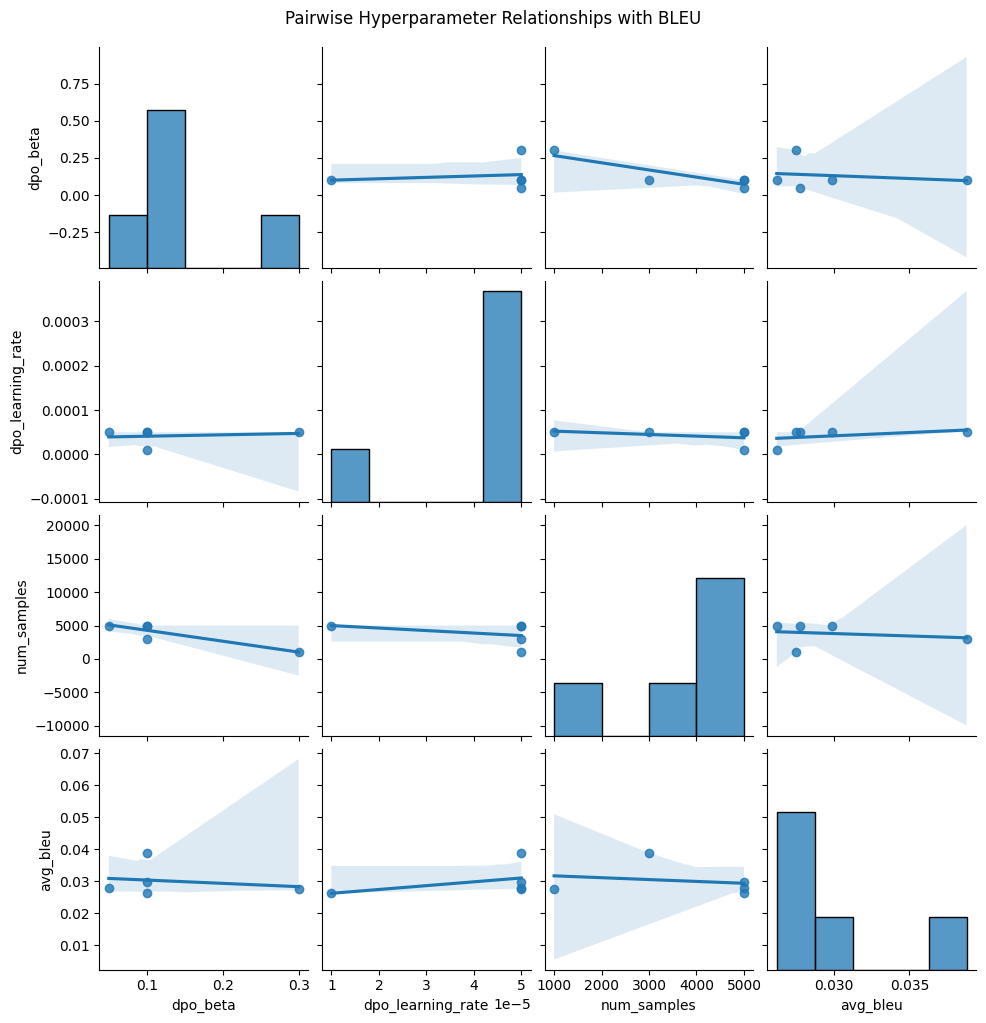

In [ ]:
# Pairplot of beta, learning rate, samples vs avg BLEU
sns.pairplot(lora_df, vars=['dpo_beta', 'dpo_learning_rate', 'num_samples', 'avg_bleu'], kind='reg')
plt.suptitle("Pairwise Hyperparameter Relationships with BLEU", y=1.02)
plt.show()

In [19]:
lora_df.columns

Index(['CASE', 'CHANGE', 'timestamp', 'training_time_mins', 'base_model',
       'dataset', 'num_samples', 'lora_r', 'lora_alpha', 'lora_dropout',
       'lora_target_modules', 'epochs', 'learning_rate', 'batch_size',
       'grad_accum', 'max_length', 'bleu_base_avg', 'bleu_lora_avg',
       'analysis', 'q1_base', 'q1_lora', 'bleu1_base', 'bleu1_lora', 'q2_base',
       'q2_lora', 'bleu2_base', 'bleu2_lora', 'q3_base', 'q3_lora',
       'bleu3_base', 'bleu3_lora', 'q4_base', 'q4_lora', 'bleu4_base',
       'bleu4_lora', 'q5_base', 'q5_lora', 'bleu5_base', 'bleu5_lora',
       'q6_base', 'q6_lora', 'bleu6_base', 'bleu6_lora', 'q7_base', 'q7_lora',
       'bleu7_base', 'bleu7_lora', 'q8_base', 'q8_lora', 'bleu8_base',
       'bleu8_lora', 'q9_base', 'q9_lora', 'bleu9_base', 'bleu9_lora',
       'q10_base', 'q10_lora', 'bleu10_base', 'bleu10_lora'],
      dtype='object')

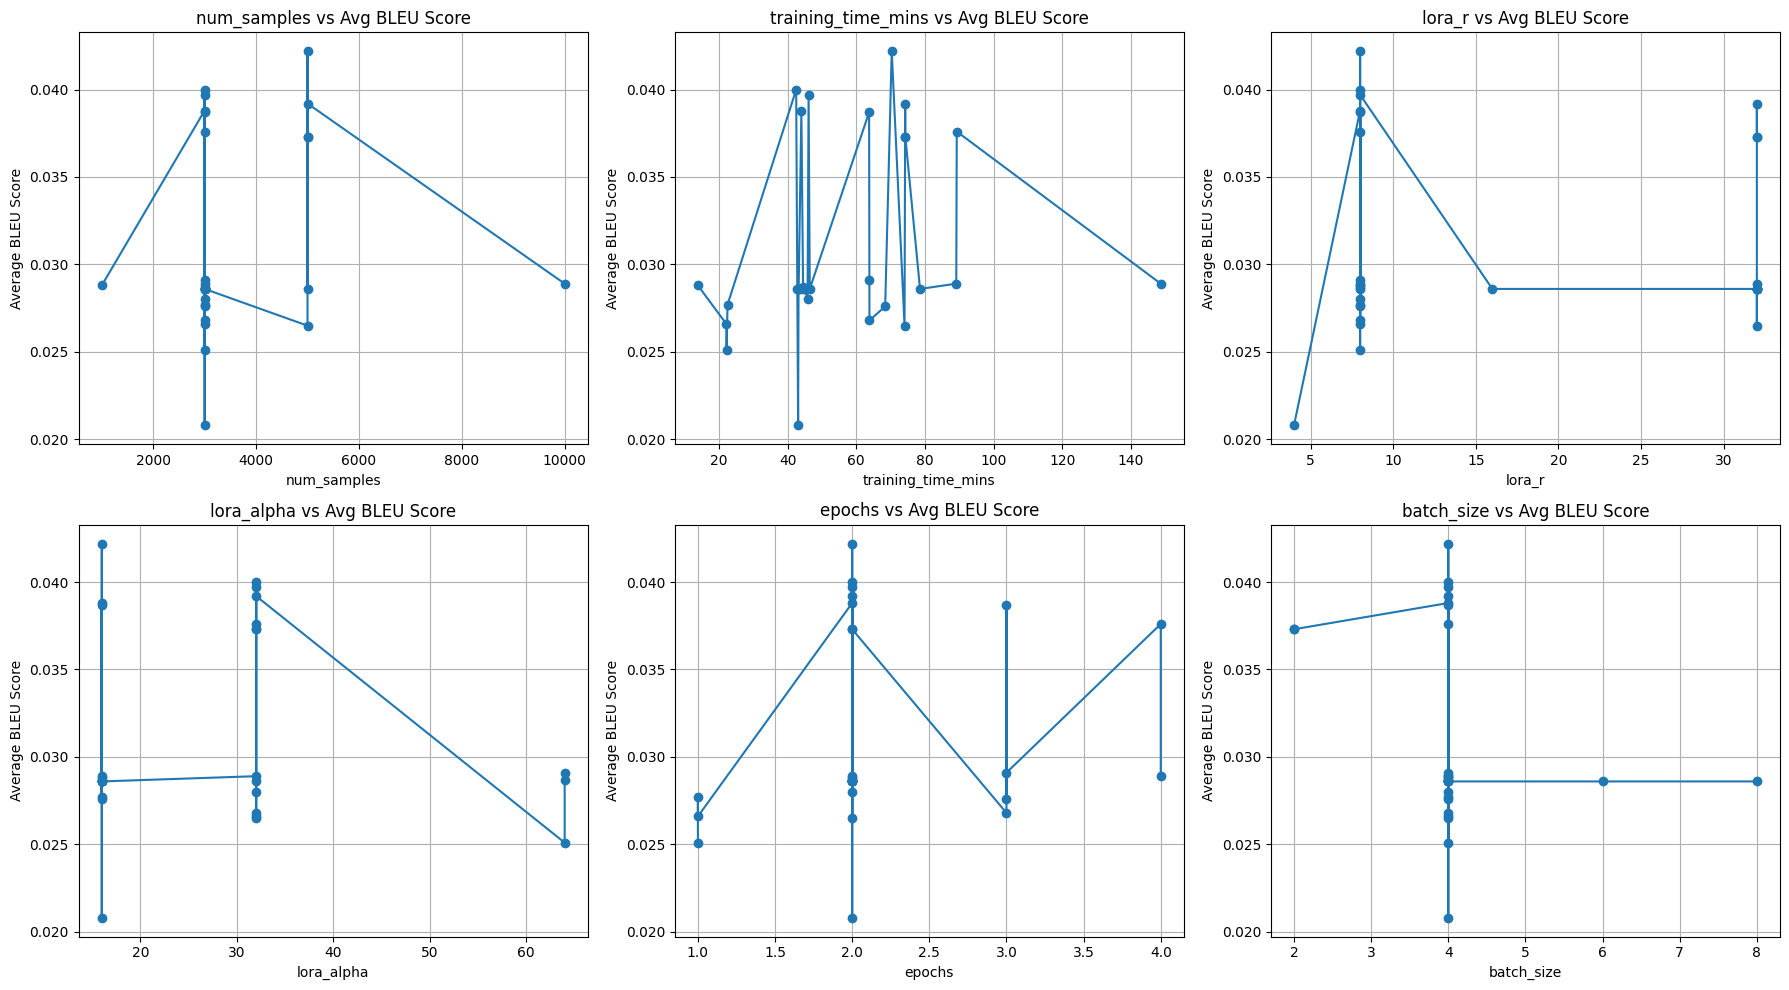

In [26]:
import matplotlib.pyplot as plt
import math

# List of parameters to visualize
param_cols = ['num_samples', 'training_time_mins', 'lora_r', 'lora_alpha', 
               'epochs', 
              'batch_size']

# Filter out parameters not in the DataFrame (if any)
param_cols = [col for col in param_cols if col in lora_df.columns]

# Total subplots needed
num_params = len(param_cols)
cols = 3
rows = math.ceil(num_params / cols)

# Create subplots
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten()

# Plot each parameter against BLEU
for i, param in enumerate(param_cols):
    sorted_df = lora_df.sort_values(by=param)

    axes[i].plot(sorted_df[param], sorted_df['bleu_lora_avg'], marker='o', linestyle='-')
    axes[i].set_title(f"{param} vs Avg BLEU Score")
    axes[i].set_xlabel(param)
    axes[i].set_ylabel("Average BLEU Score")
    axes[i].grid(True)

# Hide unused subplots
for j in range(num_params, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
